# Air Quality Prediction in Istanbul  
## Project 2: Regression Modeling

**Course:** Introduction to Machine Learning YZM2001

**Student:** Berina Juković

**Date:** May 2026

---

### Problem Overview
This project aims to analyze air quality and weather data in Istanbul and predict PM2.5 concentration levels using pollution and environmental factors.

### GitHub Repository

You can find the full project repository here:  
https://github.com/bjukovic/Istanbul-Air-Quality-YZM2011-Project-Spring2026

## 1. Recap & Motivation

- This project continues the analysis of air quality and weather conditions in Istanbul using a merged environmental dataset developed in Project 1. In Project 1, I combined historical pollution measurements (`air_quality_historical.csv`) with weather observations (`weather.csv`) based on date. After merging the datasets, the data was cleaned, explored, and analyzed to better understand how pollution and weather variables relate to unhealthy air conditions in Istanbul. 

- For this regression task, the target variable is `pm2_5`, which represents the concentration of fine particulate matter (PM2.5) in the air. PM2.5 is an important air-quality indicator because high concentrations can negatively affect human health.

- The exploratory analysis from Project 1 helped identify the most relevant pollution and weather variables for predicting PM2.5 levels. These findings guide the feature selection and modelling choices used in this project.

## 2. Feature Engineering

To improve the regression model for `pm2_5`, several additional features were created to capture temporal patterns, nonlinear relationships, and combined weather effects. These engineered features may help the models better understand how environmental conditions influence PM2.5 concentration levels.

- **Datetime decomposition:** The `month` and `day_of_week` features were extracted from the date column to capture seasonal and weekly pollution patterns.

- **Polynomial feature:** A squared version of the `pm10` variable (`pm10_squared`) was created to help capture possible nonlinear relationships between PM10 and PM2.5 concentrations.

- **Interaction term:** An interaction feature between wind speed and humidity (`wind_humidity_interaction`) was created to represent combined atmospheric effects that may influence pollution buildup or dispersion.

- **Log transform:** A log transformation was applied to the `carbon_monoxide` variable (`log_carbon_monoxide`) to reduce skewness and lessen the influence of extreme values.

Import Libraries

In [210]:
import pandas as pd
import numpy as np

Load Dataset

In [211]:
df = pd.read_csv("cleaned_air_quality_weather.csv")

In [212]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Datetime decomposition
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek

# Polynomial feature
df['pm10_squared'] = df['pm10'] ** 2

# Interaction feature
df['wind_humidity_interaction'] = (
    df['AvgWind'] * df['AvgHumidity']
)

# Log transform
df['log_carbon_monoxide'] = np.log1p(df['carbon_monoxide'])

df.head()

,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,us_aqi,european_aqi,...,MoonSet,AvgWind,AvgHumidity,AvgPressure,unhealthy_air,month,day_of_week,pm10_squared,wind_humidity_interaction,log_carbon_monoxide
0,2013-01-01,32.690476,18.980952,243.166667,25.442857,6.316667,24.666667,0.5,NaN,NaN,...,10:29:00,17,84,1022,0,1,1,1068.667234,1428,5.497851
1,2013-01-02,90.816667,68.870833,243.166667,57.741667,6.316667,11.791667,0.5,107.904762,69.428571,...,10:59:00,4,78,1024,1,1,2,8247.666944,312,5.497851
2,2013-01-03,85.120833,68.258333,243.166667,54.129167,6.316667,8.041667,0.5,163.625000,105.125000,...,11:28:00,8,82,1028,1,1,3,7245.556267,656,5.497851
3,2013-01-04,58.016667,47.866667,243.166667,33.491667,6.316667,27.625000,0.5,149.500000,86.375000,...,11:58:00,14,77,1021,1,1,4,3365.933611,1078,5.497851
4,2013-01-05,37.275000,34.100000,243.166667,36.583333,6.316667,21.000000,0.5,99.625000,67.916667,...,0:29:00,12,72,1013,1,1,5,1389.425625,864,5.497851


## 3. Train / Validation / Test Split

The dataset was divided into training, validation, and test sets using a 60% / 20% / 20% split. The training set is used to train the models, the validation set is used for model selection and hyperparameter tuning, and the test set is reserved for final evaluation.

This split was chosen to provide enough data for model training while still keeping separate datasets for validation and unbiased performance testing. Using separate validation and test sets helps reduce the risk of overfitting model choices to the final evaluation data.

Feature scaling was applied after splitting the data in order to prevent data leakage. StandardScaler was used to standardize numerical features so that variables with different scales contribute more evenly to the regression models.

In [213]:
features = [
    'pm10',
    'carbon_monoxide',
    'nitrogen_dioxide',
    'sulphur_dioxide',
    'ozone',
    'MaxTemp',
    'MinTemp',
    'AvgHumidity',
    'AvgWind',
    'AvgPressure',
    'month',
    'day_of_week',
    'pm10_squared',
    'wind_humidity_interaction',
    'log_carbon_monoxide'
]

target = 'pm2_5'

X = df[features]
y = df[target]

In [214]:
from sklearn.model_selection import train_test_split

# First split: 60% train, 40% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42
)

# Second split: 20% validation, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (1461, 15)
Validation set: (487, 15)
Test set: (488, 15)


Apply Feature Scaling

In [215]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

Target Distribution Across Splits

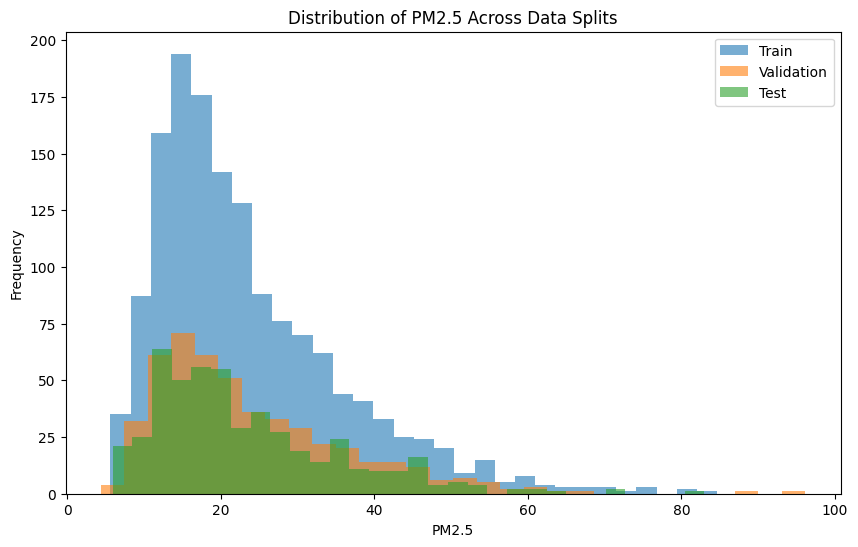

In [216]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(y_train, bins=30, alpha=0.6, label='Train')
plt.hist(y_val, bins=30, alpha=0.6, label='Validation')
plt.hist(y_test, bins=30, alpha=0.6, label='Test')

plt.xlabel('PM2.5')
plt.ylabel('Frequency')
plt.title('Distribution of PM2.5 Across Data Splits')

plt.legend()

plt.show()

The distributions across the train, validation, and test sets appear reasonably similar, suggesting that the split preserved the overall PM2.5 distribution.

## 4. Baseline Model

As a baseline model, a simple linear regression model was trained using only one predictor variable: `pm10`. This baseline provides a simple reference point for evaluating whether more advanced models and engineered features improve prediction performance.

The model was evaluated using R², RMSE, and MAE on both the training and validation sets.

In [217]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import numpy as np

Train Baseline Model

In [218]:
baseline_feature = ['pm10']

X_train_base = X_train[baseline_feature]
X_val_base = X_val[baseline_feature]

baseline_model = LinearRegression()

baseline_model.fit(X_train_base, y_train)

train_pred = baseline_model.predict(X_train_base)
val_pred = baseline_model.predict(X_val_base)

In [219]:
train_r2 = r2_score(y_train, train_pred)
val_r2 = r2_score(y_val, val_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
train_mae = mean_absolute_error(y_train, train_pred)

val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
val_mae = mean_absolute_error(y_val, val_pred)

print("Train R²:", round(train_r2, 4))
print("Train RMSE:", round(train_rmse, 4))
print("Train MAE:", round(train_mae, 4))
print()
print("Validation R²:", round(val_r2, 4))
print("Validation RMSE:", round(val_rmse, 4))
print("Validation MAE:", round(val_mae, 4))

Train R²: 0.8688
Train RMSE: 4.4897
Train MAE: 3.2082

Validation R²: 0.7694
Validation RMSE: 6.1037
Validation MAE: 3.1129


Predicted vs Actual Values

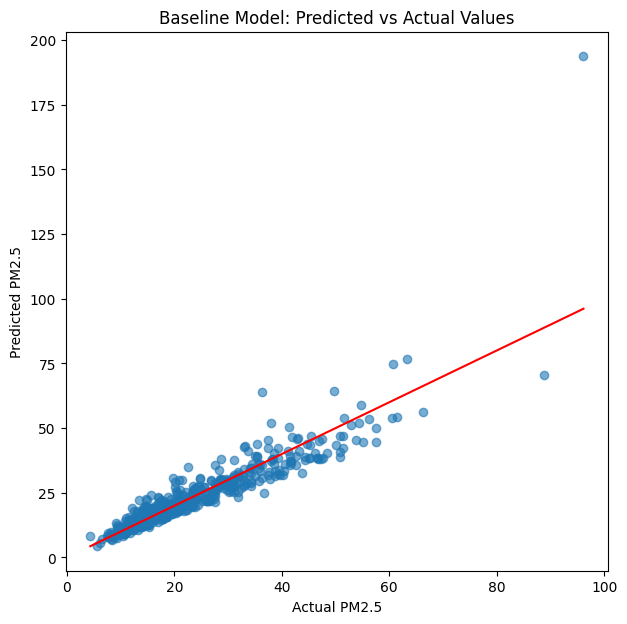

In [220]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(y_val, val_pred, alpha=0.6)

plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")

plt.title("Baseline Model: Predicted vs Actual Values")

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    color='red'
)

plt.show()

The baseline model provides a simple reference point for later regression models. Since it uses only one predictor variable, its performance is expected to be limited compared to models that use multiple features and feature engineering techniques.

## 5. Multiple Linear Regression

A multiple linear regression model was trained using all selected features and engineered variables. Unlike the baseline model, which used only PM10, this model combines pollution, weather, and engineered features to better capture the factors influencing PM2.5 concentration levels.

The model was evaluated using R², RMSE, and MAE on both the training and validation sets. In addition, coefficient analysis and residual diagnostics were performed to better understand feature importance and model behaviour.

In [221]:
multiple_lr = LinearRegression()

multiple_lr.fit(X_train_scaled, y_train)

train_pred_multi = multiple_lr.predict(X_train_scaled)
val_pred_multi = multiple_lr.predict(X_val_scaled)

In [222]:
train_r2_multi = r2_score(y_train, train_pred_multi)
val_r2_multi = r2_score(y_val, val_pred_multi)

train_rmse_multi = np.sqrt(mean_squared_error(y_train, train_pred_multi))
train_mae_multi = mean_absolute_error(y_train, train_pred_multi)

val_rmse_multi = np.sqrt(mean_squared_error(y_val, val_pred_multi))
val_mae_multi = mean_absolute_error(y_val, val_pred_multi)

print("Train R²:", round(train_r2_multi, 4))
print("Train RMSE:", round(train_rmse_multi, 4))
print("Train MAE:", round(train_mae_multi, 4))

print()

print("Validation R²:", round(val_r2_multi, 4))
print("Validation RMSE:", round(val_rmse_multi, 4))
print("Validation MAE:", round(val_mae_multi, 4))

Train R²: 0.9074
Train RMSE: 3.7713
Train MAE: 2.7381

Validation R²: 0.9084
Validation RMSE: 3.8468
Validation MAE: 2.6593


Coefficient Analysis

In [223]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': multiple_lr.coef_
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

coef_df

,Feature,Coefficient
0,pm10,10.991440
2,nitrogen_dioxide,2.794267
14,log_carbon_monoxide,1.779023
4,ozone,0.816007
7,AvgHumidity,0.762016
10,month,0.599309
6,MinTemp,0.401242
9,AvgPressure,0.309308
8,AvgWind,0.288810
11,day_of_week,0.155693


Positive coefficients indicate features associated with higher predicted PM2.5 levels, while negative coefficients indicate features associated with lower predicted PM2.5 levels. Features with larger absolute coefficient values generally have a stronger influence on the model predictions.

PM10 and related pollution variables had the strongest positive influence on predicted PM2.5 levels, while some weather variables showed weaker or negative relationships.

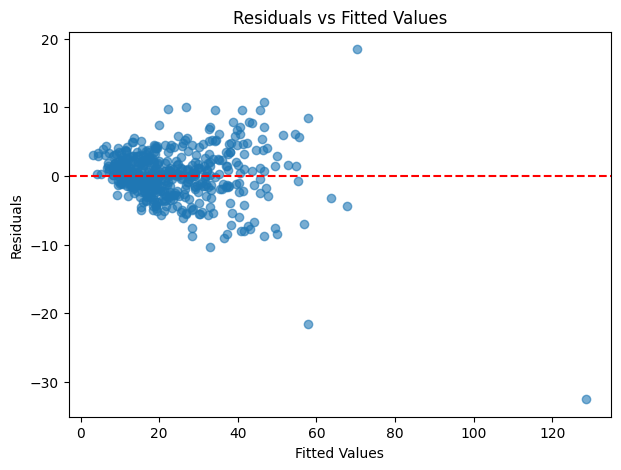

In [224]:
residuals = y_val - val_pred_multi

plt.figure(figsize=(7, 5))

plt.scatter(val_pred_multi, residuals, alpha=0.6)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.title("Residuals vs Fitted Values")

plt.show()

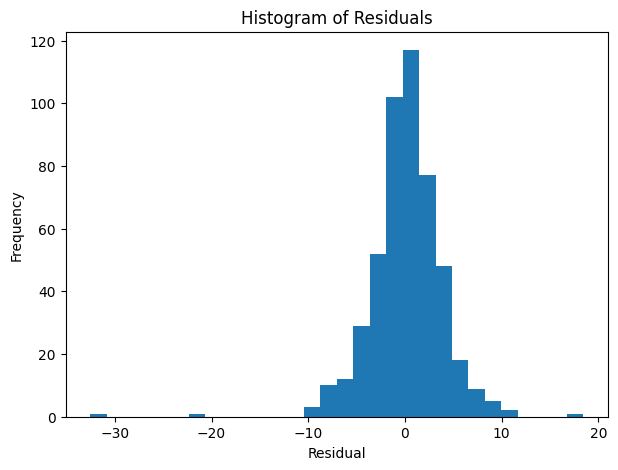

In [225]:
plt.figure(figsize=(7, 5))

plt.hist(residuals, bins=30)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.title("Histogram of Residuals")

plt.show()

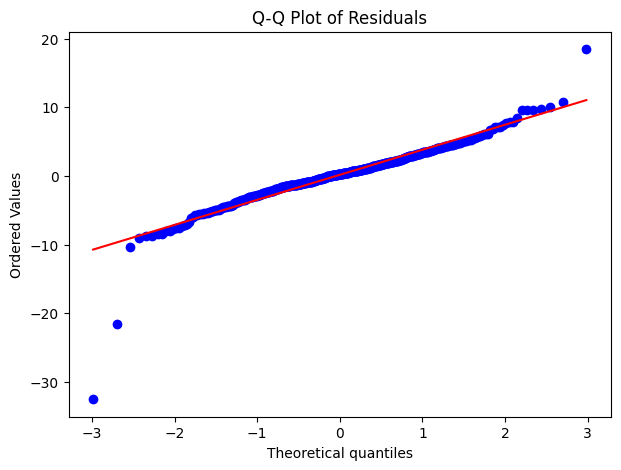

In [226]:
import scipy.stats as stats

plt.figure(figsize=(7, 5))

stats.probplot(residuals, dist="norm", plot=plt)

plt.title("Q-Q Plot of Residuals")

plt.show()

The residual plots help evaluate whether the assumptions of linear regression are reasonably satisfied. Ideally, residuals should appear randomly scattered around zero, approximately normally distributed, and without strong patterns. Large systematic patterns may indicate nonlinear relationships or model limitations.

## 6. Polynomial Regression

Polynomial regression models were trained to capture nonlinear relationships between the features and PM2.5 concentration levels. Polynomial feature expansion allows the model to learn curved and interaction-based relationships that cannot be represented by standard linear regression.

Polynomial degrees 2 and 3 were tested and compared using training and validation error. The relationship between model complexity and performance was analyzed using a bias-variance curve.

Train Polynomial Models

In [227]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [228]:
degrees = [1, 2, 3]

train_rmse_list = []
val_rmse_list = []

poly_models = {}

for degree in degrees:

    poly_model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ])

    poly_model.fit(X_train, y_train)

    train_pred_poly = poly_model.predict(X_train)
    val_pred_poly = poly_model.predict(X_val)

    train_rmse = np.sqrt(
        mean_squared_error(y_train, train_pred_poly)
    )

    val_rmse = np.sqrt(
        mean_squared_error(y_val, val_pred_poly)
    )

    train_rmse_list.append(train_rmse)
    val_rmse_list.append(val_rmse)

    poly_models[degree] = poly_model

    print(f"Degree {degree}")
    print("Train RMSE:", round(train_rmse, 4))
    print("Validation RMSE:", round(val_rmse, 4))
    print()

Degree 1
Train RMSE: 3.7713
Validation RMSE: 3.8468

Degree 2
Train RMSE: 3.0599
Validation RMSE: 60.8417

Degree 3
Train RMSE: 1.8694
Validation RMSE: 17429.414



Bias-Variance Curve

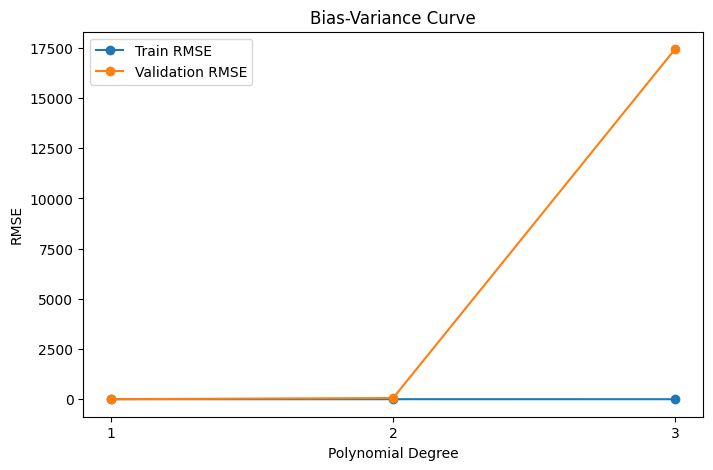

In [229]:
plt.figure(figsize=(8, 5))

plt.plot(
    degrees,
    train_rmse_list,
    marker='o',
    label='Train RMSE'
)

plt.plot(
    degrees,
    val_rmse_list,
    marker='o',
    label='Validation RMSE'
)

plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")

plt.title("Bias-Variance Curve")

plt.xticks(degrees)

plt.legend()

plt.show()

In [230]:
best_degree = degrees[np.argmin(val_rmse_list)]

best_poly_model = poly_models[best_degree]

print("Best polynomial degree:", best_degree)

Best polynomial degree: 1


In [231]:
train_pred_poly = best_poly_model.predict(X_train)
val_pred_poly = best_poly_model.predict(X_val)

train_r2_poly = r2_score(y_train, train_pred_poly)
val_r2_poly = r2_score(y_val, val_pred_poly)

print("Train R²:", round(train_r2_poly, 4))
print("Validation R²:", round(val_r2_poly, 4))

Train R²: 0.9074
Validation R²: 0.9084


Lower-degree polynomial models may underfit the data because they are too simple to capture nonlinear relationships. Higher-degree polynomial models are more flexible but may overfit the training data, resulting in worse validation performance.

The best polynomial degree was selected based on the lowest validation RMSE. This degree provides the best balance between model complexity and generalization performance. Although degree 2 and degree 3 polynomial models were tested, degree 1 had the best validation performance. This suggests that higher-degree polynomial expansions overfit the training data and did not improve generalization.

## 7. Regularization

Regularization techniques were applied to reduce overfitting and improve model generalization. Ridge regression (L2 regularization) and Lasso regression (L1 regularization) were both tested using cross-validation to automatically select the best regularization strength parameter (α).

Ridge regression reduces the magnitude of coefficients without removing features completely, while Lasso regression can shrink some coefficients to zero, effectively performing feature selection. The performance of these regularized models was compared with the plain multiple linear regression model.

In [232]:
from sklearn.linear_model import RidgeCV, LassoCV

Train Ridge Regression

In [233]:
ridge = RidgeCV(
    alphas=[0.01, 0.1, 1, 10, 100],
    cv=5
)

ridge.fit(X_train_scaled, y_train)

train_pred_ridge = ridge.predict(X_train_scaled)
val_pred_ridge = ridge.predict(X_val_scaled)

print("Best Ridge alpha:", ridge.alpha_)

Best Ridge alpha: 0.01


In [234]:
train_r2_ridge = r2_score(y_train, train_pred_ridge)
val_r2_ridge = r2_score(y_val, val_pred_ridge)

train_rmse_ridge = np.sqrt(
    mean_squared_error(y_train, train_pred_ridge)
)

val_rmse_ridge = np.sqrt(
    mean_squared_error(y_val, val_pred_ridge)
)

train_mae_ridge = mean_absolute_error(
    y_train,
    train_pred_ridge
)

val_mae_ridge = mean_absolute_error(
    y_val,
    val_pred_ridge
)

print("Train R²:", round(train_r2_ridge, 4))
print("Train RMSE:", round(train_rmse_ridge, 4))
print("Train MAE:", round(train_mae_ridge, 4))

print()

print("Validation R²:", round(val_r2_ridge, 4))
print("Validation RMSE:", round(val_rmse_ridge, 4))
print("Validation MAE:", round(val_mae_ridge, 4))

Train R²: 0.9074
Train RMSE: 3.7713
Train MAE: 2.7381

Validation R²: 0.9084
Validation RMSE: 3.8473
Validation MAE: 2.6593


Train Lasso Regression

In [235]:
lasso = LassoCV(
    alphas=[0.001, 0.01, 0.1, 1, 10],
    cv=5,
    max_iter=10000
)

lasso.fit(X_train_scaled, y_train)

train_pred_lasso = lasso.predict(X_train_scaled)
val_pred_lasso = lasso.predict(X_val_scaled)

print("Best Lasso alpha:", lasso.alpha_)

Best Lasso alpha: 0.01


In [236]:
train_r2_lasso = r2_score(y_train, train_pred_lasso)
val_r2_lasso = r2_score(y_val, val_pred_lasso)

train_rmse_lasso = np.sqrt(
    mean_squared_error(y_train, train_pred_lasso)
)

val_rmse_lasso = np.sqrt(
    mean_squared_error(y_val, val_pred_lasso)
)

train_mae_lasso = mean_absolute_error(
    y_train,
    train_pred_lasso
)

val_mae_lasso = mean_absolute_error(
    y_val,
    val_pred_lasso
)

print("Train R²:", round(train_r2_lasso, 4))
print("Train RMSE:", round(train_rmse_lasso, 4))
print("Train MAE:", round(train_mae_lasso, 4))

print()

print("Validation R²:", round(val_r2_lasso, 4))
print("Validation RMSE:", round(val_rmse_lasso, 4))
print("Validation MAE:", round(val_mae_lasso, 4))

Train R²: 0.9072
Train RMSE: 3.775
Train MAE: 2.7312

Validation R²: 0.902
Validation RMSE: 3.9794
Validation MAE: 2.6706


### Lasso Feature Selection

In [237]:
lasso_coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lasso.coef_
})

lasso_coef_df

,Feature,Coefficient
0,pm10,10.778678
1,carbon_monoxide,-0.902255
2,nitrogen_dioxide,2.677777
3,sulphur_dioxide,-0.843495
4,ozone,0.764446
5,MaxTemp,-0.909491
6,MinTemp,0.000000
7,AvgHumidity,0.678942
8,AvgWind,-0.101820
9,AvgPressure,0.299879


In [238]:
zeroed_features = lasso_coef_df[
    lasso_coef_df['Coefficient'] == 0
]

zeroed_features

,Feature,Coefficient
6,MinTemp,0.0


Lasso reduced MinTemp to zero, suggesting that this feature did not provide significant additional predictive value once the other pollution and weather variables were included.

Features with coefficients reduced to zero by Lasso regression are considered less useful for predicting PM2.5 in the presence of the other variables. This may indicate that these features provide redundant information or have relatively weak relationships with the target variable.

Compared to the plain multiple linear regression model, Ridge and Lasso regression help reduce overfitting by penalizing large coefficients. Ridge keeps all features while shrinking coefficient values, whereas Lasso can simplify the model by removing less important features entirely.

## 8. Model Comparison

The performance of all regression models was compared using R², RMSE, and MAE metrics. Training and validation metrics were used during model development, while the test set was reserved for final evaluation on unseen data.

The goal of this comparison is to determine which model provides the best balance between predictive performance and generalization ability.

In [239]:
test_pred_base = baseline_model.predict(
    X_test[baseline_feature]
)

test_r2_base = r2_score(y_test, test_pred_base)

test_rmse_base = np.sqrt(
    mean_squared_error(y_test, test_pred_base)
)

test_mae_base = mean_absolute_error(
    y_test,
    test_pred_base
)

In [240]:
test_pred_multi = multiple_lr.predict(
    X_test_scaled
)

test_r2_multi = r2_score(y_test, test_pred_multi)

test_rmse_multi = np.sqrt(
    mean_squared_error(y_test, test_pred_multi)
)

test_mae_multi = mean_absolute_error(
    y_test,
    test_pred_multi
)

In [241]:
best_poly_model = poly_models[best_degree]

test_pred_poly = best_poly_model.predict(X_test)

test_r2_poly = r2_score(y_test, test_pred_poly)

test_rmse_poly = np.sqrt(
    mean_squared_error(y_test, test_pred_poly)
)

test_mae_poly = mean_absolute_error(
    y_test,
    test_pred_poly
)

In [242]:
test_pred_ridge = ridge.predict(X_test_scaled)

test_r2_ridge = r2_score(y_test, test_pred_ridge)

test_rmse_ridge = np.sqrt(
    mean_squared_error(y_test, test_pred_ridge)
)

test_mae_ridge = mean_absolute_error(
    y_test,
    test_pred_ridge
)

In [243]:
test_pred_lasso = lasso.predict(X_test_scaled)

test_r2_lasso = r2_score(y_test, test_pred_lasso)

test_rmse_lasso = np.sqrt(
    mean_squared_error(y_test, test_pred_lasso)
)

test_mae_lasso = mean_absolute_error(
    y_test,
    test_pred_lasso
)

Create Comparison Table

In [244]:
comparison_df = pd.DataFrame({

    'Model': [
        'Baseline (Simple LR)',
        'Multiple LR',
        f'Polynomial (Degree {best_degree})',
        'Ridge',
        'Lasso'
    ],

    'Train R²': [
        train_r2,
        train_r2_multi,
        train_r2_poly,
        train_r2_ridge,
        train_r2_lasso
    ],

    'Val R²': [
        val_r2,
        val_r2_multi,
        val_r2_poly,
        val_r2_ridge,
        val_r2_lasso
    ],

    'Test R²': [
        test_r2_base,
        test_r2_multi,
        test_r2_poly,
        test_r2_ridge,
        test_r2_lasso
    ],

    'RMSE (Test)': [
        test_rmse_base,
        test_rmse_multi,
        test_rmse_poly,
        test_rmse_ridge,
        test_rmse_lasso
    ],

    'MAE (Test)': [
        test_mae_base,
        test_mae_multi,
        test_mae_poly,
        test_mae_ridge,
        test_mae_lasso
    ]

})

comparison_df.round(4)

,Model,Train R²,Val R²,Test R²,RMSE (Test),MAE (Test)
0,Baseline (Simple LR),0.8688,0.7694,0.8460,4.7932,3.2525
1,Multiple LR,0.9074,0.9084,0.8911,4.0313,2.8695
2,Polynomial (Degree 1),0.9074,0.9084,0.8911,4.0313,2.8695
3,Ridge,0.9074,0.9084,0.8911,4.0313,2.8695
4,Lasso,0.9072,0.9020,0.8912,4.0295,2.8479


The comparison table shows the performance of all regression models across the training, validation, and test datasets. The baseline model provides the simplest reference point, while the more advanced models use multiple features, nonlinear relationships, and regularization techniques.

The best model was selected based on validation and test performance, with particular attention to generalization ability rather than only training accuracy. A model with very high training performance but weaker validation or test performance may indicate overfitting.

### Final Model Selection

The selected final model was the model with the best validation and test performance while maintaining good generalization ability. Final test-set metrics for the chosen model are reported below.

In [245]:
print("Final Selected Model: Lasso Regression")
print("Test R²:", round(test_r2_lasso, 4))
print("Test RMSE:", round(test_rmse_lasso, 4))
print("Test MAE:", round(test_mae_lasso, 4))

Final Selected Model: Lasso Regression
Test R²: 0.8912
Test RMSE: 4.0295
Test MAE: 2.8479


## 9. Interpretation & Reflection

The regression results show that PM2.5 levels in Istanbul can be predicted reasonably well using a combination of pollution measurements, weather variables, and engineered features. Models using multiple features generally performed better than the baseline model, indicating that air quality is influenced by several environmental factors working together rather than a single variable alone. Feature engineering and regularization techniques also helped improve model performance and reduce overfitting.

The predictions are useful for understanding general pollution trends and estimating PM2.5 concentration levels, although the models are not perfectly accurate. Air quality is affected by many complex environmental and human factors, so some prediction error is expected. The models are more suitable for identifying overall pollution patterns than for making perfectly precise daily forecasts.

The main sources of error likely include measurement noise, missing environmental factors, seasonal variation, sudden weather changes, traffic fluctuations, and limitations in the available dataset. Some relationships between weather and pollution variables may also be nonlinear or influenced by external factors that are not included in the dataset.

These findings will help guide the modelling choices in Project 3. Since several pollution and weather variables showed strong predictive value in the regression models, they can also be useful features for classification models predicting unhealthy air conditions. The comparison between simpler and more complex models in this project also provides insight into balancing model complexity and generalization performance for future classification tasks.